<a href="https://colab.research.google.com/github/Rupasunkara125/Projects/blob/main/loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv(r"/content/Loan_approval_data_2025.csv")

In [ ]:
data

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST149995,35,Employed,4.3,39449,570,16.3,1127,7576,0,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,0
49996,CUST149996,34,Employed,4.4,20496,672,12.6,1478,6276,1,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,0
49997,CUST149997,41,Self-Employed,4.8,18743,719,10.1,17,10331,0,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,0
49998,CUST149998,38,Student,0.4,17250,633,1.3,5,7779,0,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,0


In [ ]:
data.shape

(50000, 20)

In [ ]:
data.isna().sum()

,0
customer_id,0
age,0
occupation_status,0
years_employed,0
annual_income,0
credit_score,0
credit_history_years,0
savings_assets,0
current_debt,0
defaults_on_file,0


In [ ]:
data = data.drop('customer_id', axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()

In [ ]:
cols=['occupation_status','product_type','loan_intent']
for col in cols:
  data[col]=label.fit_transform(data[col])

In [ ]:
data

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,0,17.2,25579,692,5.3,895,10820,0,0,0,0,0,600,17.02,0.423,0.023,0.008,1
1,33,0,7.3,43087,627,3.5,169,16550,0,1,0,2,3,53300,14.10,0.384,1.237,0.412,0
2,42,2,1.1,20840,689,8.4,17,7852,0,0,0,0,1,2100,18.33,0.377,0.101,0.034,1
3,53,2,0.5,29147,692,9.8,1480,11603,0,1,0,0,0,2900,18.74,0.398,0.099,0.033,1
4,32,0,12.5,63657,630,7.2,209,12424,0,0,0,2,2,99600,13.92,0.195,1.565,0.522,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,35,0,4.3,39449,570,16.3,1127,7576,0,0,0,0,2,42800,21.31,0.192,1.085,0.362,0
49996,34,0,4.4,20496,672,12.6,1478,6276,1,0,0,0,5,3800,18.07,0.306,0.185,0.062,0
49997,41,1,4.8,18743,719,10.1,17,10331,0,0,0,0,5,18000,17.45,0.551,0.960,0.320,0
49998,38,2,0.4,17250,633,1.3,5,7779,0,0,1,2,5,1400,14.71,0.451,0.081,0.027,0


In [ ]:
x=data.drop('loan_status',axis=1)
y=data['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=23,stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
predict=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict)

0.8452

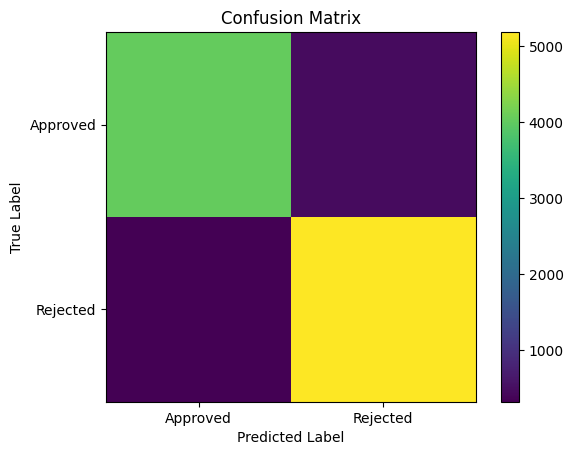

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(2), ['Approved','Rejected'])
plt.yticks(np.arange(2), ['Approved','Rejected'])

plt.colorbar()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model1=RandomForestClassifier()
model1.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
predict1=model1.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict1)

0.9136

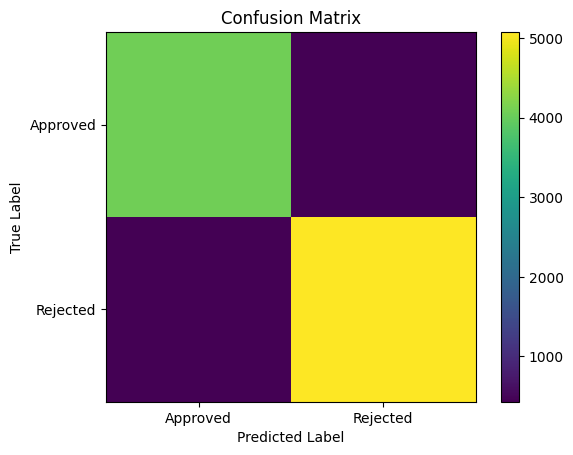

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict1)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(2), ['Approved','Rejected'])
plt.yticks(np.arange(2), ['Approved','Rejected'])

plt.colorbar()
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
Gradient=GradientBoostingClassifier()
Gradient.fit(x_train,y_train)

GradientBoostingClassifier()

In [ ]:
predict2=Gradient.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict2)

0.9229

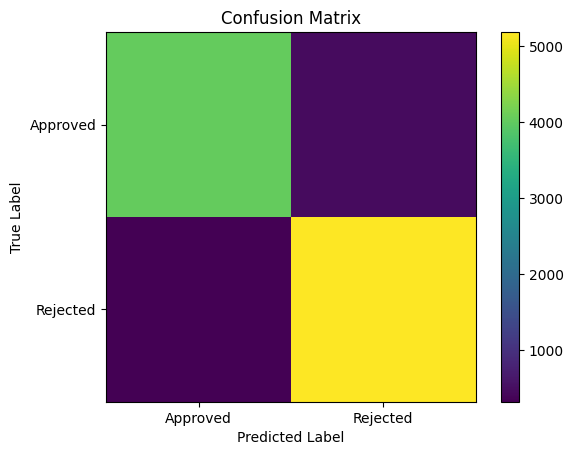

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict2)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(2), ['Approved','Rejected'])
plt.yticks(np.arange(2), ['Approved','Rejected'])

plt.colorbar()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
model3=LinearRegression()
model3.fit(x_train,y_train)

LinearRegression()

In [ ]:
predict3=Gradient.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict3)

0.9229

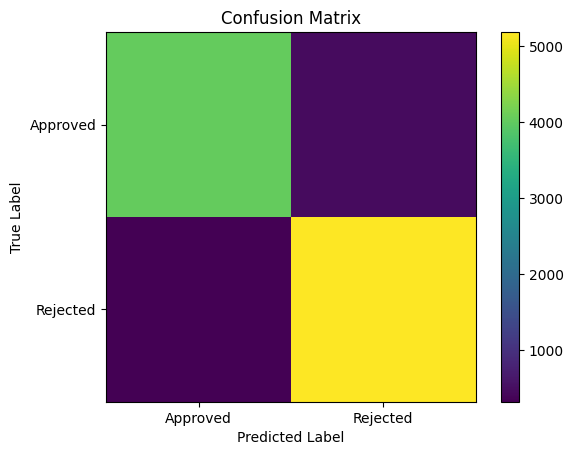

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict3)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(2), ['Approved','Rejected'])
plt.yticks(np.arange(2), ['Approved','Rejected'])

plt.colorbar()
plt.show()

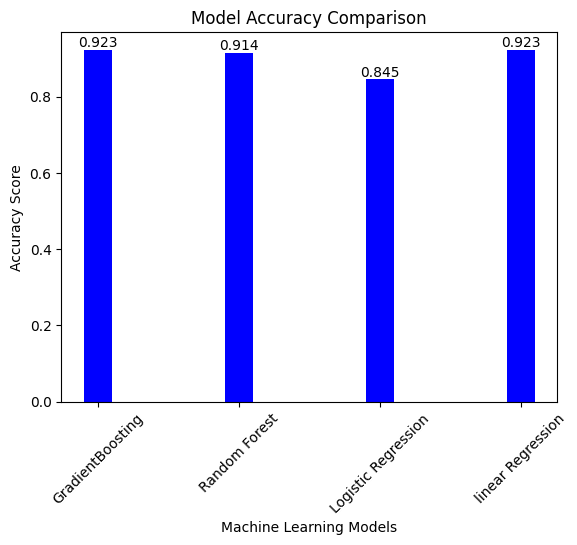

In [ ]:
import matplotlib.pyplot as plt

models = [
    "GradientBoosting",
    "Random Forest",
    "Logistic Regression",
    "linear Regression"
]
scores = [
    0.9229,
    0.9136,
    0.8452,
    0.9229
]
plt.figure()
plt.bar(models, scores, width=0.2)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=45)
bars = plt.bar(models, scores, width=0.2,color='blue')
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y,3),
             ha='center', va='bottom')
plt.show()
plt.show()